In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/cleaned/restaurant_cleaned.csv', parse_dates=['order_date'])

# Set visual style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)

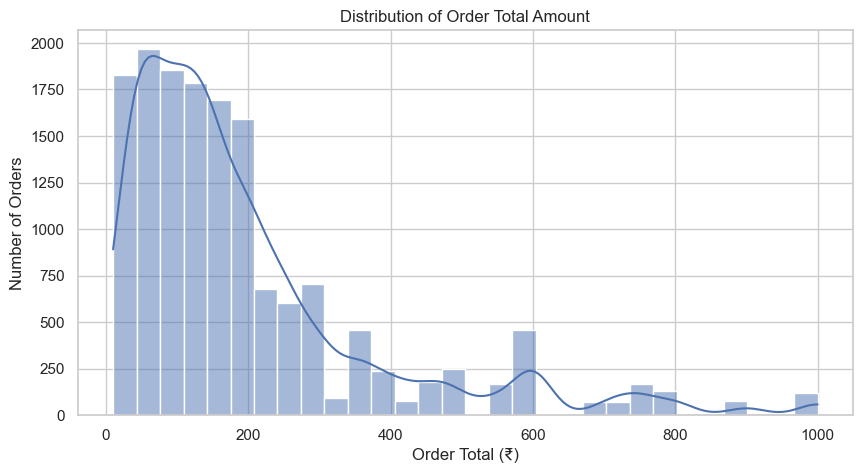

In [2]:
sns.histplot(df['total_amt'], bins=30, kde=True)
plt.title('Distribution of Order Total Amount')
plt.xlabel('Order Total (₹)')
plt.ylabel('Number of Orders')
plt.savefig('../visuals/revenue_distribution.png', dpi=150)
plt.show()

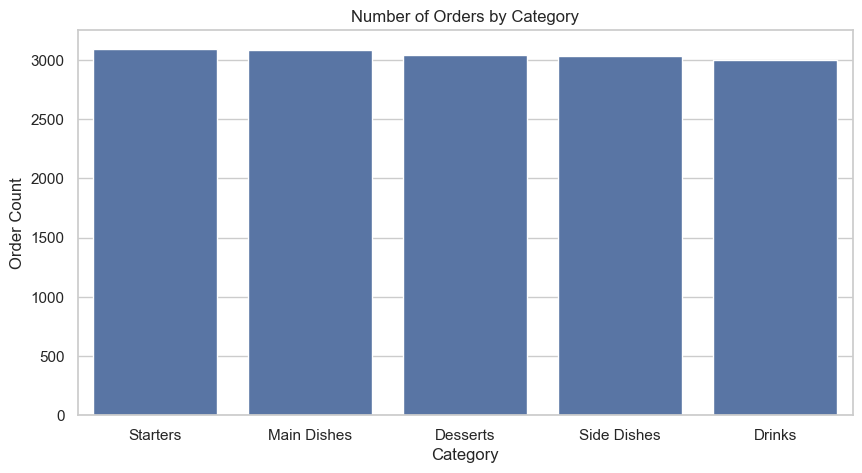

In [3]:
sns.countplot(data=df, x='category', order=df['category'].value_counts().index)

plt.title('Number of Orders by Category')
plt.xlabel('Category')
plt.ylabel('Order Count')

plt.savefig('../visuals/category_count.png', dpi=150)

plt.show()

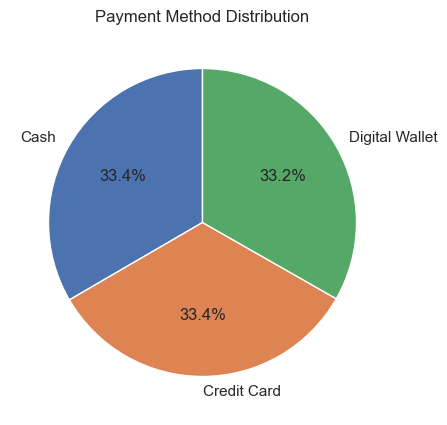

In [4]:
payment_counts = df['payment_method'].value_counts()

plt.pie(payment_counts, labels=payment_counts.index, autopct='%.1f%%', startangle=90)

plt.title('Payment Method Distribution')
plt.savefig('../visuals/payment_method_distribution.png', dpi=150)
plt.show()

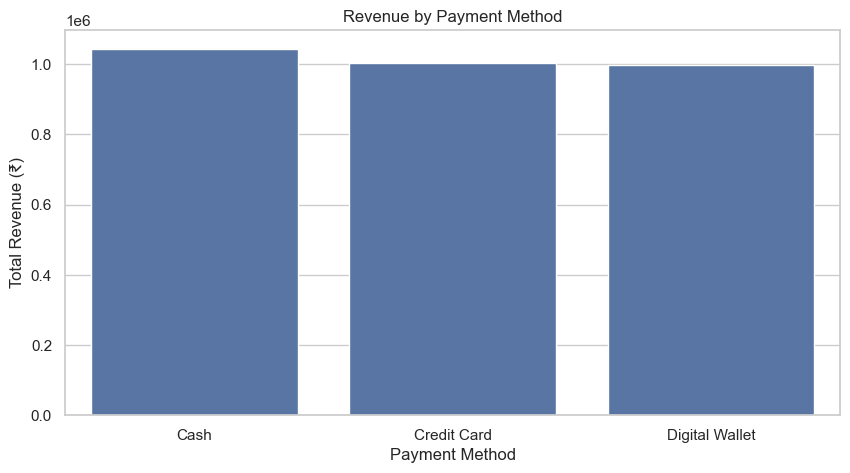

In [5]:
pay_rev = df.groupby('payment_method', as_index=False)['total_amt'].sum()
pay_rev = pay_rev.sort_values('total_amt', ascending=False)

sns.barplot(data=pay_rev, x='payment_method', y='total_amt')

plt.title('Revenue by Payment Method')
plt.xlabel('Payment Method')
plt.ylabel('Total Revenue (₹)')

plt.savefig('../visuals/revenue_by_payment_method.png', dpi=150)

plt.show()

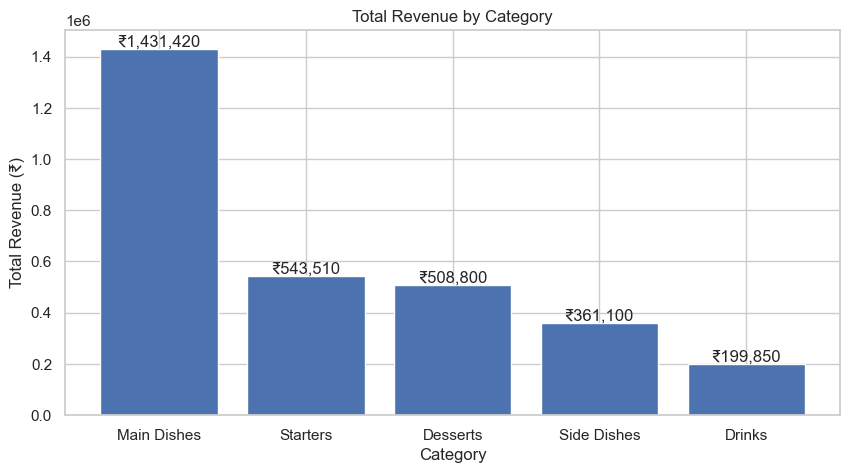

In [6]:
cat_revenue = df.groupby('category', as_index=False)['total_amt'].sum()
cat_revenue = cat_revenue.sort_values('total_amt', ascending=False)

bars = plt.bar(cat_revenue['category'], cat_revenue['total_amt'])

plt.title('Total Revenue by Category')
plt.xlabel('Category')
plt.ylabel('Total Revenue (₹)')

# Add value labels
for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 10000,
             f"₹{bar.get_height():,.0f}",
             ha='center')

plt.savefig('../visuals/revenue_by_category.png', dpi=150)
plt.show()

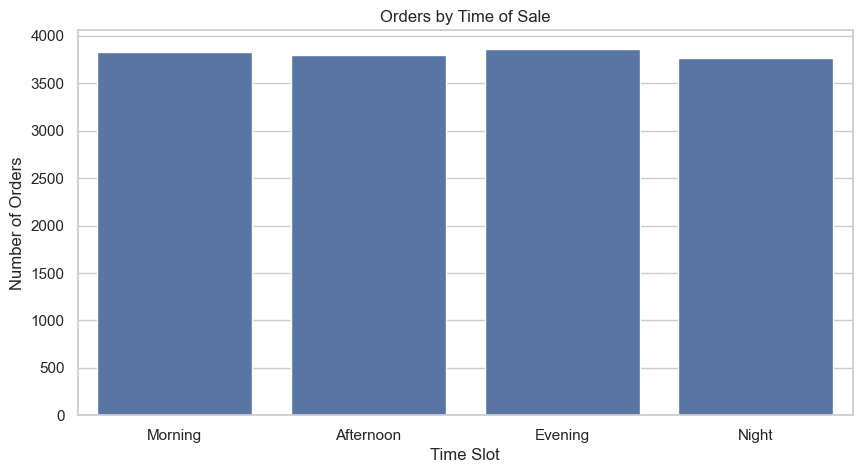

In [7]:
time_order = ['Morning', 'Afternoon', 'Evening', 'Night']

sns.countplot(data=df, x='time_of_sale', order=time_order, legend=False)

plt.title('Orders by Time of Sale')
plt.xlabel('Time Slot')
plt.ylabel('Number of Orders')

plt.savefig('../visuals/time_of_sale.png', dpi=150)
plt.show()

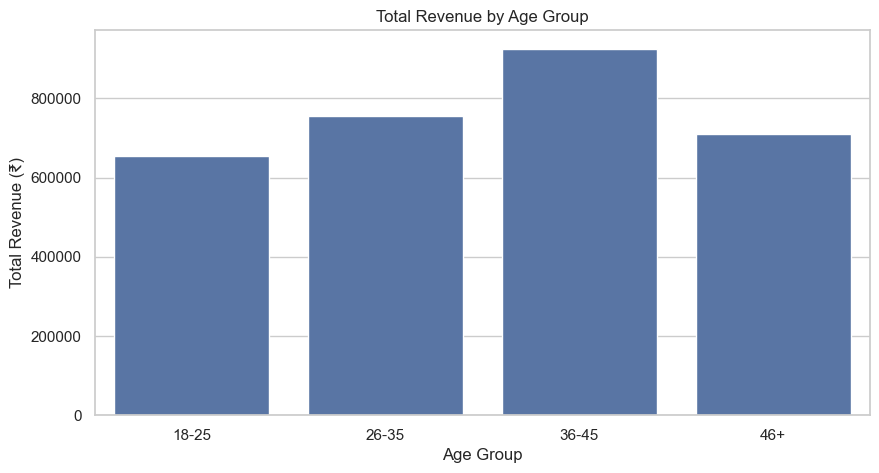

In [8]:
age_order = ['18-25', '26-35', '36-45', '46+']

age_rev = df.groupby('age_group', as_index=False)['total_amt'].sum()

sns.barplot(data=age_rev, x='age_group', y='total_amt', order=age_order)

plt.title('Total Revenue by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Total Revenue (₹)')

plt.savefig('../visuals/revenue_by_age.png', dpi=150)

plt.show()

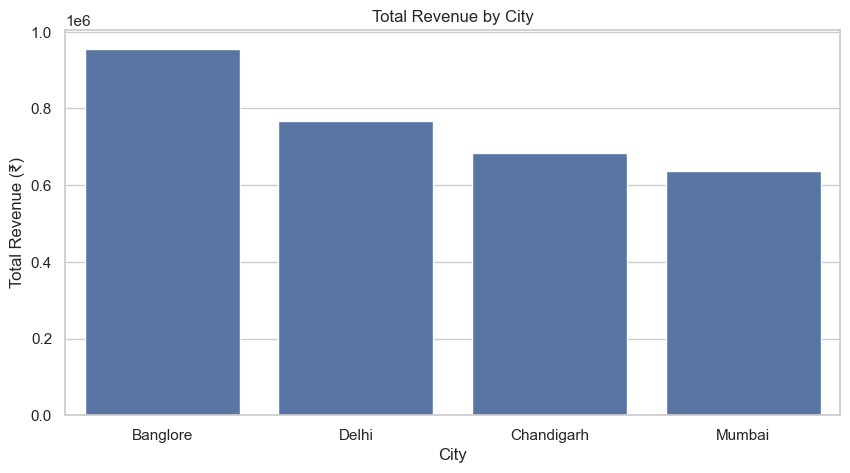

In [9]:
city_rev = df.groupby('city', as_index=False)['total_amt'].sum()
city_rev = city_rev.sort_values('total_amt', ascending=False)

sns.barplot(data=city_rev, x='city', y='total_amt')

plt.title('Total Revenue by City')
plt.xlabel('City')
plt.ylabel('Total Revenue (₹)')

plt.savefig('../visuals/revenue_by_city.png', dpi=150)
plt.show()

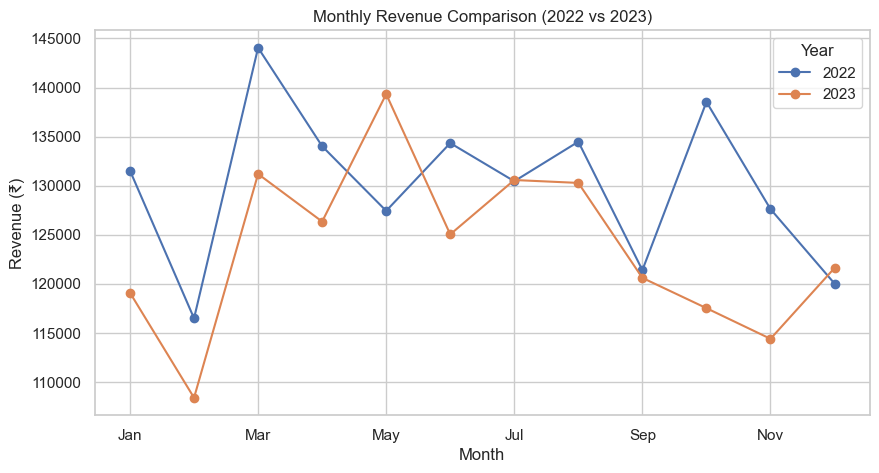

In [10]:
df['Year'] = df['order_date'].dt.year
df['Month'] = df['order_date'].dt.strftime('%b')

monthly_rev = df.groupby(['Year', 'Month'])['total_amt'].sum().unstack()

monthly_rev = monthly_rev[['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']]

monthly_rev.T.plot(marker='o')

plt.title('Monthly Revenue Comparison (2022 vs 2023)')
plt.xlabel('Month')
plt.ylabel('Revenue (₹)')

plt.savefig('../visuals/monthly_revenue_comparison.png', dpi=150)
plt.show()

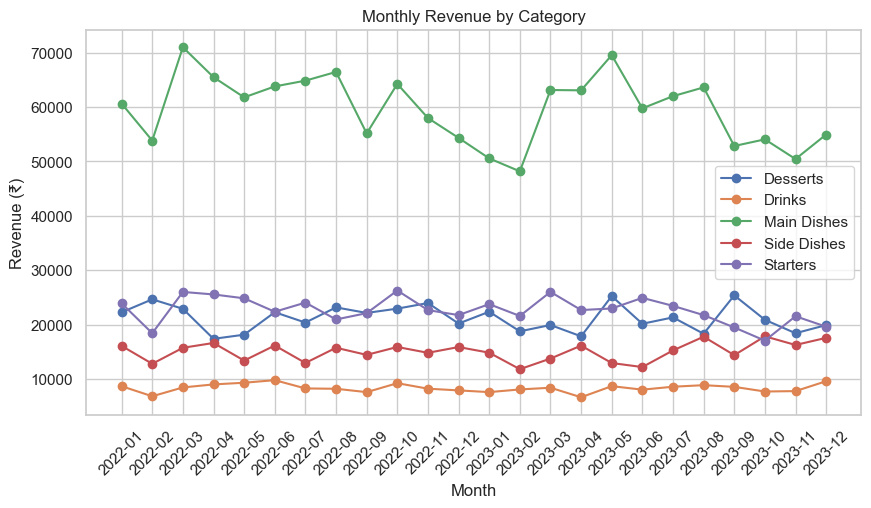

In [11]:
df['year_month'] = df['order_date'].dt.to_period('M')

cat_monthly = df.groupby(['year_month', 'category'], as_index=False)['total_amt'].sum()
cat_monthly['year_month'] = cat_monthly['year_month'].astype(str)

for cat in cat_monthly['category'].unique():
    subset = cat_monthly[cat_monthly['category'] == cat]
    plt.plot(subset['year_month'], subset['total_amt'], marker='o', label=cat)

plt.title('Monthly Revenue by Category')
plt.xlabel('Month')
plt.ylabel('Revenue (₹)')
plt.xticks(rotation=45)
plt.legend()

plt.savefig('../visuals/category_monthly_trend.png', dpi=150)
plt.show()

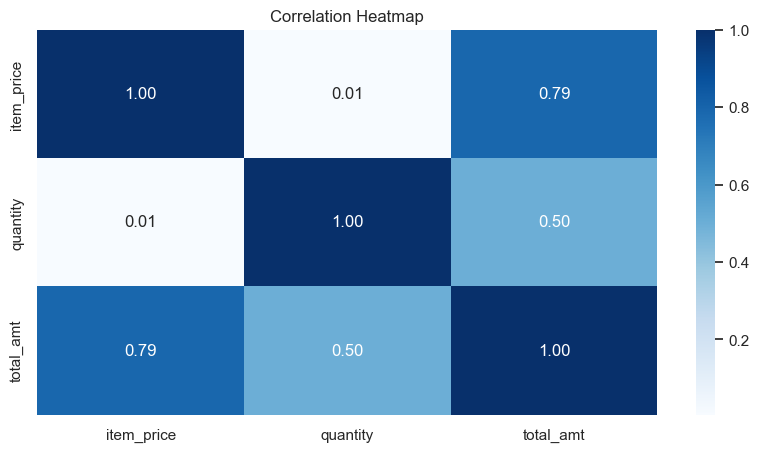

In [12]:
corr = df[['item_price', 'quantity', 'total_amt']].corr()

sns.heatmap(corr, annot=True, cmap='Blues', fmt='.2f') 

plt.title('Correlation Heatmap')
plt.savefig('../visuals/correlation_heatmap.png', dpi=150)
plt.show()

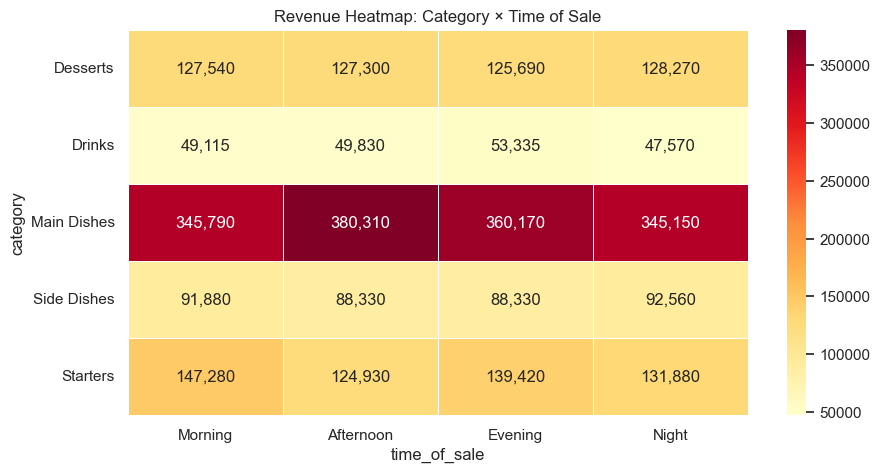

In [13]:
pivot = df.pivot_table(values='total_amt', index='category', columns='time_of_sale', aggfunc='sum')
pivot = pivot[['Morning', 'Afternoon', 'Evening', 'Night']]

sns.heatmap(pivot, annot=True, fmt=',', cmap='YlOrRd', linewidths=0.5)

plt.title('Revenue Heatmap: Category × Time of Sale')
plt.savefig('../visuals/category_time_heatmap.png', dpi=150)
plt.show()
